In [2]:
# Add the local source directory to Python path so imports from src/ work correctly.
import os
import sys

sys.path.append(os.path.abspath("../src"))
print(f"Added '../src' to sys.path: {sys.path[-1]}")


Added '../src' to sys.path: /Users/rana/Projects/autonomous-perception-stack/src


In [7]:
from pipeline.fusion_pipeline import (
    run_fusion_pipeline
)

from bev.scene_builder import (
    build_bev_scene
)

In [3]:
# Load the NuScenes dataset helper using the project's data loader.
from data_loader import load_nuscenes

nusc = load_nuscenes()
print(f"Loaded NuScenes dataset, number of scenes: {len(nusc.scene)}")

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.114 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Loaded NuScenes dataset, number of scenes: 10


In [4]:
# Select the first scene and retrieve the first sample for sensor synchronization.
scene = nusc.scene[0]
print(f"Using scene token: {scene['token']}")

sample = nusc.get("sample", scene["first_sample_token"])
print(f"Loaded first sample token: {sample['token']}")

# Get the front camera and top lidar sample data tokens.
cam_token = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]
print(f"Camera token: {cam_token}")
print(f"Lidar token: {lidar_token}")

cam_data = nusc.get("sample_data", cam_token)
lidar_data = nusc.get("sample_data", lidar_token)
print(f"Loaded camera data filename: {cam_data['filename']}")
print(f"Loaded lidar data filename: {lidar_data['filename']}")


Using scene token: cc8c0bf57f984915a77078b10eb33198
Loaded first sample token: ca9a282c9e77460f8360f564131a8af5
Camera token: e3d495d4ac534d54b321f50006683844
Lidar token: 9d9bf11fb0e144c8b446d54a8a00184f
Loaded camera data filename: samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Loaded lidar data filename: samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [5]:
# Load and convert the front camera image to RGB for visualization and pipeline input.
import cv2
import os

img_path = os.path.join(nusc.dataroot, cam_data["filename"])
print(f"Reading image from: {img_path}")

image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Image file not found: {img_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image shape: {image.shape}, dtype: {image.dtype}")


Reading image from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
Image shape: (900, 1600, 3), dtype: uint8


In [6]:
# Run the fusion pipeline that combines camera and lidar data for object localization.
from pipeline.fusion_pipeline import run_fusion_pipeline

results = run_fusion_pipeline(nusc, image, cam_data, lidar_data)
objects = results.get("objects", [])
print(f"Fusion pipeline completed. Result keys: {list(results.keys())}")
print(f"Detected {len(objects)} objects from fusion pipeline.")

Fusion pipeline completed. Result keys: ['detections', 'u', 'v', 'points_cam', 'pointcloud', 'fused_objects', 'objects']
Detected 7 objects from fusion pipeline.


In [8]:

objects = (
    results["objects"]
)

bev_objects = (
    build_bev_scene(
        objects
    )
)

In [9]:
from bev.occupancy_grid import (
    create_grid
)

from bev.occupancy_mapper import (
    populate_grid
)

grid = (
    create_grid()
)

grid = (
    populate_grid(
        grid,
        bev_objects
    )
)

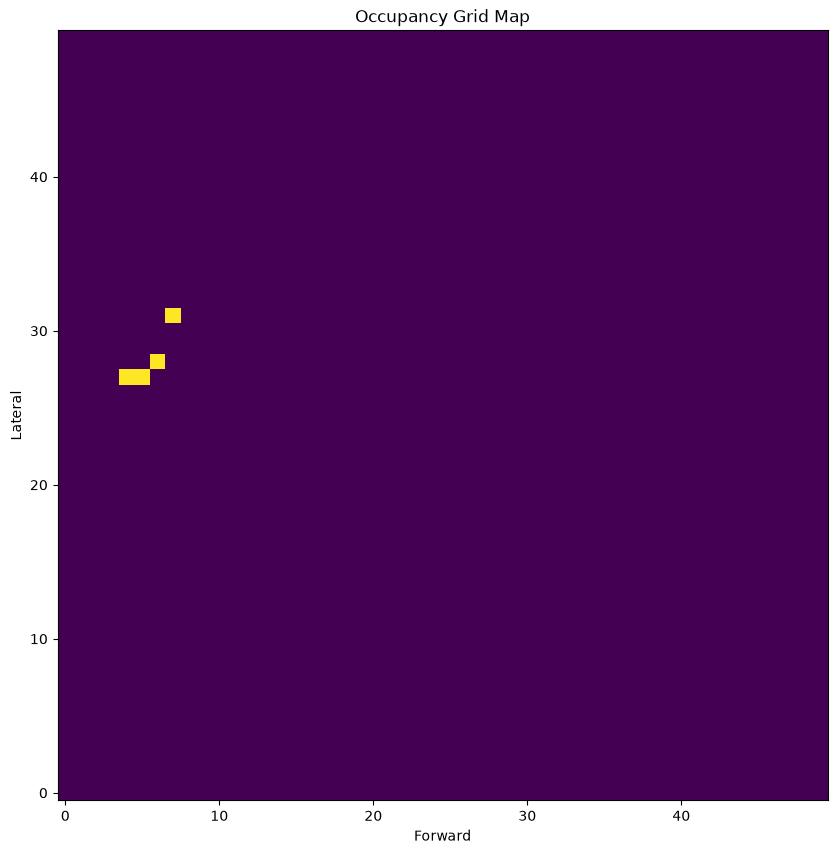

In [10]:
from visualization.occupancy_view import (
    visualize_occupancy_grid
)

visualize_occupancy_grid(
    grid,
    save_path=
    "../outputs/images/occupancy_grid.png"
)

In [11]:
from bev.grid_utils import (
    occupancy_statistics
)

occupancy_statistics(
    grid
)

{'occupied': 4, 'free': 2496, 'occupancy_ratio': 0.0016}

In [ ]:
if objects:
    print(objects[0]["points_lidar"].shape)
else:
    print("No objects available for point-cloud inspection.")
